# 🔀 Unified AI API - Validation Tests

## Overview

Validate the Unified AI Wildcard API (`/unified-ai`) across different model providers and API patterns.

This notebook tests:
- **Access Contract Provisioning**: Deploy an access contract via Bicep to obtain API credentials
- **Model & Deployment Discovery**: List available models, get deployment by name, and validate 404 for non-existent models
- **Azure OpenAI Pattern**: `/unified-ai/openai/deployments/{model}/chat/completions`
- **Inference Pattern (Foundry)**: `/unified-ai/models/chat/completions`
- **Responses API Pattern**: `/unified-ai/openai/responses` (if supported)
- **Gemini OpenAI Pattern**: `/unified-ai/v1beta/openai/chat/completions`
- **Authentication Modes**: API Key validation (valid, missing, invalid) and cross-product isolation
- **Load Testing**: Concurrent requests with throttling visualization
- **UAIG Debug Headers**: Validate all `UAIG-*` response headers from gateway fragments
- **Blocked Path Rejection**: Verify unrecognized paths return 403 PathNotAllowed
- **Model Access Control**: Verify `allowedModels` enforcement from product policy
- **Streaming Requests**: Validate `stream: true` detection and SSE response handling

> **Prerequisites:** An existing Citadel Governance Hub deployment with the Unified AI API enabled.

### 0️⃣ Initialize Notebook Variables

Configure the following variables according to your environment before running the notebook:

In [1]:
import os
import sys, json, requests, time
sys.path.insert(1, '../shared')  # add the shared directory to the Python path
import utils
from apimtools import APIMClientTool

# ============================================================================
# 🔧 GOVERNANCE HUB CONFIGURATION (REQUIRED)
# ============================================================================
governance_hub_resource_group = "rg-ai-hub-citadel-dev-57"   # Resource group of the deployed Citadel Governance Hub
location = "swedencentral"                         # Azure region (e.g. "swedencentral", "eastus")

# ============================================================================
# 🔧 API VERSION CONFIGURATION
# ============================================================================
inference_api_version = "2024-05-01-preview"
openai_api_version    = "2024-12-01-preview"
targetInferenceApi    = "models"             # 'models' = Universal LLM API | 'openai' = Azure OpenAI API

# ============================================================================
# 🧠 MODEL CONFIGURATION (REPLACE based on your configured backends)
# ============================================================================
openai_model            = "gpt-5.2"               # Azure OpenAI model
foundry_inference_model = "Mistral-Large-3"       # AI Foundry inference model
gemini_model            = "gemini-2.5-flash-lite" # Gemini model (if Gemini backend configured)

# Feature toggles
test_responses_api = True  # Set True if your backend supports the Responses API
test_gemini        = False  # Set True if a Gemini backend is configured

# ============================================================================
# 📜 ACCESS CONTRACT CONFIGURATION (created on the fly by this notebook)
# ============================================================================
contract_business_unit = "Testing"
contract_use_case_name = "UnifiedAI"
contract_environment   = "DEV"

# ============================================================================
# 🔐 KEY VAULT / 🤖 FOUNDRY (this notebook does not require either)
# ============================================================================
use_keyvault_integration = False
use_foundry_integration  = False

# Need shutil for the dynamic-policy generation cell below
import shutil


utils.print_ok("Notebook variables initialized!")


✅ Notebook variables initialized! ⌚ 17:36:54.920231 


### 1️⃣ Verify Azure CLI and Connected Subscription

In [2]:
output = utils.run("az account show", "Retrieved az account", "Failed to get the current az account")

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:37:02.011651 :4s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d


### 2️⃣ Initialize APIM Client Tool

Discover the Unified AI API and retrieve gateway configuration:

In [3]:
try:
    apimClientTool = APIMClientTool(governance_hub_resource_group)
    apimClientTool.initialize()
    apimClientTool.discover_api("unified-ai")

    apim_resource_gateway_url = str(apimClientTool.apim_resource_gateway_url)
    azure_endpoint = str(apimClientTool.azure_endpoint)

    # Get supported models from the policy fragment
    supported_models = apimClientTool.get_policy_fragment_supported_models("set-backend-pools")
    utils.print_info(f"Supported models: {supported_models}")

    utils.print_ok(f"Testing tool initialized successfully!")
except Exception as e:
    utils.print_error(f"Error initializing APIM Client Tool: {e}")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 17:37:02.859414 :0s]
👉🏽 Current user: admin@MngEnvMCAP242328.onmicrosoft.com
👉🏽 Tenant ID: a578ad63-b9b6-47fe-b80a-fb375e759417
👉🏽 Subscription ID: d2e7f84f-2790-4baa-9520-59ae8169ed0d
⚙️ Running: az resource list -g rg-ai-hub-citadel-dev-57 --resource-type Microsoft.ApiManagement/service 
✅ Listing APIM Resources ⌚ 17:37:05.693250 :2s]
👉🏽 APIM Service Id: /subscriptions/d2e7f84f-2790-4baa-9520-59ae8169ed0d/resourceGroups/rg-ai-hub-citadel-dev-57/providers/Microsoft.ApiManagement/service/apim-dmdxocmlhenr4
👉🏽 APIM Gateway URL: https://apim-dmdxocmlhenr4.azure-api.net
👉🏽 Retrieved key 0 for subscription: master
👉🏽 Retrieved key 1 for subscription: LLM-Sales-Assistant-DEV-SUB-01
👉🏽 Retrieved key 2 for subscription: LLM-HR-ChatAgent-DEV-SUB-01
👉🏽 Retrieved key 3 for subscription: LLM-Support-Bot-DEV-SUB-01
👉🏽 Retrieved key 4 for subscription: LLM-Testing-UnifiedAI-DEV-SUB-01
👉🏽 Retrieved key 5 for subscription: LLM-HR-PIIMasking-DEV-SU

### 3️⃣ Provision Access Contract

Deploy an access contract via Bicep to create an APIM product and subscription for testing the Unified AI API.
This grants API credentials scoped to the unified-ai-api.

In [13]:
bicep_dir = "../bicep/infra/citadel-access-contracts"
template_file = os.path.join(bicep_dir, "main.bicep")

timestamp = time.strftime('%Y%m%d%H%M%S')
contract_name = f"unified-ai-test-{timestamp}"

# Create folder structure: contracts/[businessunit-usecase]/[environment]/
folder_name = f"{contract_business_unit.lower()}-{contract_use_case_name.lower()}"
environment_folder = contract_environment.lower()
contract_folder = os.path.join(bicep_dir, "contracts", folder_name, environment_folder)
os.makedirs(contract_folder, exist_ok=True)
utils.print_info(f"📁 Created folder: {contract_folder}")

# Build allowedModels from the notebook model variables
allowed_models_list = [openai_model, foundry_inference_model]
if test_gemini:
    allowed_models_list.append(gemini_model)
allowed_models_csv = ",".join(allowed_models_list)
utils.print_info(f"Allowed models for access contract: {allowed_models_csv}")

# Generate custom product policy with allowedModels scoped to the test models
product_policy = f'''<policies>
    <inbound>
        <base />
        <!-- Extract and validate model parameter from request -->
        <include-fragment fragment-id="set-llm-requested-model" />

        <!-- Setting allowed models to only the models defined in notebook parameters -->
        <set-variable name="allowedModels" value="{allowed_models_csv}" />

        <!-- Capacity management -->
        <llm-token-limit counter-key="@(context.Subscription.Id)" tokens-per-minute="1000" estimate-prompt-tokens="false" token-quota="100000" token-quota-period="Monthly" />

        <!-- Enable advanced response headers offered by set-response-headers fragment -->
        <set-variable name="enableResponseHeaders" value="@(true)" />
    </inbound>
    <backend>
        <base />
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
    </on-error>
</policies>'''

# Write the custom policy file
policy_file_dest = os.path.join(contract_folder, "ai-product-policy.xml")
with open(policy_file_dest, 'w') as f:
    f.write(product_policy)
utils.print_ok(f"📋 Custom policy file created: {policy_file_dest}")

params_file = os.path.join(contract_folder, "main.bicepparam")

params_content = f"""using '../../../main.bicep'

// ============================================================================
// Unified AI API Test Contract - Generated from Notebook
// ============================================================================

param apim = {{
  subscriptionId: '{subscription_id}'
  resourceGroupName: '{governance_hub_resource_group}'
  name: '{apimClientTool.apim_resource_name}'
}}

param keyVault = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  name: 'placeholder'
}}

param useTargetAzureKeyVault = false

param useCase = {{
  businessUnit: '{contract_business_unit}'
  useCaseName: '{contract_use_case_name}'
  environment: '{contract_environment}'
}}

param apiNameMapping = {{
  LLM: ['unified-ai-api']
}}

param services = [
  {{
    code: 'LLM'
    endpointSecretName: 'UNIFIED-AI-TEST-ENDPOINT'
    apiKeySecretName: 'UNIFIED-AI-TEST-KEY'
    policyXml: loadTextContent('ai-product-policy.xml')
  }}
]

param productTerms = 'Unified AI API test contract - generated from validation notebook'

// Azure AI Foundry Integration (disabled)
param useTargetFoundry = false

param foundry = {{
  subscriptionId: '00000000-0000-0000-0000-000000000000'
  resourceGroupName: 'placeholder'
  accountName: 'placeholder'
  projectName: 'placeholder'
}}
"""

with open(params_file, 'w') as f:
    f.write(params_content)
utils.print_ok(f"✅ Parameter file created: {params_file}")

# Deploy the access contract
product_id = f"LLM-{contract_business_unit}-{contract_use_case_name}-{contract_environment}"
utils.print_info(f"Deploying access contract: {contract_name} (Product: {product_id})...")

deployment_cmd = f"az deployment sub create --name {contract_name} --location {location} --template-file {template_file} --parameters {params_file}"
output = utils.run(deployment_cmd, f"Deployment '{contract_name}' succeeded", f"Deployment '{contract_name}' failed")

if output.success:
    utils.print_ok(f"✅ Access contract deployed! Product ID: {product_id}")
else:
    utils.print_error(f"❌ Access contract deployment failed!")

# Re-initialize APIM client to pick up the new subscription
apimClientTool.initialize()

👉🏽 📁 Created folder: ../bicep/infra/citadel-access-contracts\contracts\testing-unifiedai\dev
👉🏽 Allowed models for access contract: gpt-5.2,Mistral-Large-3
✅ 📋 Custom policy file created: ../bicep/infra/citadel-access-contracts\contracts\testing-unifiedai\dev\ai-product-policy.xml ⌚ 17:47:09.953489 
✅ ✅ Parameter file created: ../bicep/infra/citadel-access-contracts\contracts\testing-unifiedai\dev\main.bicepparam ⌚ 17:47:09.954487 
👉🏽 Deploying access contract: unified-ai-test-20260423174709 (Product: LLM-Testing-UnifiedAI-DEV)...
⚙️ Running: az deployment sub create --name unified-ai-test-20260423174709 --location swedencentral --template-file ../bicep/infra/citadel-access-contracts\main.bicep --parameters ../bicep/infra/citadel-access-contracts\contracts\testing-unifiedai\dev\main.bicepparam 
✅ Deployment 'unified-ai-test-20260423174709' succeeded ⌚ 17:48:04.864990 :54s]
✅ ✅ Access contract deployed! Product ID: LLM-Testing-UnifiedAI-DEV ⌚ 17:48:04.865989 
⚙️ Running: az account show

### 4️⃣ Retrieve API Key from Access Contract

Get the subscription key created by the access contract deployment:

In [5]:
subscription_name = f"{product_id}-SUB-01"

api_key = None
for sub in apimClientTool.apim_subscriptions:
    if subscription_name.lower() in sub.get('name', '').lower():
        api_key = sub.get('key')
        utils.print_ok(f"Found API key from subscription: {sub.get('name')}")
        break

if not api_key:
    raise Exception(f"No API key found for subscription '{subscription_name}'. Ensure the access contract was deployed successfully.")

# Build endpoint URLs for different API patterns
base_url = azure_endpoint.rstrip('/')
openai_url = f"{base_url}/unified-ai/openai/deployments/{openai_model}/chat/completions?api-version={openai_api_version}"
inference_url = f"{base_url}/unified-ai/models/chat/completions?api-version={inference_api_version}"
gemini_url = f"{base_url}/unified-ai/v1beta/openai/chat/completions"
deployments_url = f"{base_url}/unified-ai/deployments"

utils.print_info(f"OpenAI endpoint: {openai_url}")
utils.print_info(f"Inference endpoint: {inference_url}")
utils.print_info(f"Deployments endpoint: {deployments_url}")
utils.print_ok(f"API key and endpoints configured successfully!")

✅ Found API key from subscription: LLM-Testing-UnifiedAI-DEV-SUB-01 ⌚ 17:38:26.199469 
👉🏽 OpenAI endpoint: https://apim-dmdxocmlhenr4.azure-api.net/unified-ai/openai/deployments/gpt-5.2/chat/completions?api-version=2024-12-01-preview
👉🏽 Inference endpoint: https://apim-dmdxocmlhenr4.azure-api.net/unified-ai/models/chat/completions?api-version=2024-05-01-preview
👉🏽 Deployments endpoint: https://apim-dmdxocmlhenr4.azure-api.net/unified-ai/deployments
✅ API key and endpoints configured successfully! ⌚ 17:38:26.199469 


### 5️⃣ Discover Available Models & Deployment Discovery

List available models through the Unified AI API, validate `GET /unified-ai/deployments` listing, and test `GET /unified-ai/deployments/{name}` lookup:

In [6]:
## Part A: List all available deployments
utils.print_info("Listing all available deployments via the Unified AI API...")

try:
    response = requests.get(
        deployments_url,
        headers={'api-key': api_key},
        timeout=30
    )

    utils.print_response_code(response)

    if response.status_code == 200:
        data = json.loads(response.text)
        available_deployments = data.get("value", [])
        utils.print_ok(f"Found {len(available_deployments)} allowed models per access contract:")
        for d in available_deployments:
            name = d.get('name', 'unknown')
            model_format = d.get('properties', {}).get('model', {}).get('format', 'N/A')
            utils.print_info(f"  • {name} (format: {model_format})")
    else:
        utils.print_error(f"Error listing deployments: {response.text[:300]}")
        available_deployments = []
except Exception as e:
    utils.print_error(f"Request failed: {e}")
    available_deployments = []

# Cross-reference with policy-supported models
utils.print_info(f"\nGateway all supported models: {supported_models}")
deployment_names = [d.get('name', '') for d in available_deployments]
matched_models = [m for m in supported_models if m in deployment_names]
utils.print_ok(f"Models available for testing: {matched_models if matched_models else supported_models}")

## Part B: Get specific deployment by name (should return 200)
utils.print_info(f"\nGetting deployment: {openai_model}")

try:
    response = requests.get(
        f"{deployments_url}/{openai_model}",
        headers={'api-key': api_key},
        timeout=30
    )

    utils.print_response_code(response)
    if response.status_code == 200:
        data = json.loads(response.text)
        utils.print_ok(f"Found deployment: {data.get('name', 'unknown')}")
    else:
        utils.print_error(f"Unexpected: {response.text[:200]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

## Part C: Get non-existent deployment (should return 404)
utils.print_info(f"Getting non-existent deployment: nonexistent-model-xyz")

try:
    response = requests.get(
        f"{deployments_url}/nonexistent-model-xyz",
        headers={'api-key': api_key},
        timeout=30
    )

    if response.status_code == 404:
        utils.print_ok(f"Correctly returned 404 for non-existent model")
    else:
        utils.print_error(f"Unexpected status {response.status_code}: {response.text[:200]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Listing all available deployments via the Unified AI API...
Response status: 200 - OK
✅ Found 2 allowed models per access contract: ⌚ 17:38:26.925813 
👉🏽   • Mistral-Large-3 (format: Mistral AI)
👉🏽   • gpt-5.2 (format: OpenAI)
👉🏽 
Gateway all supported models: ['DeepSeek-R1', 'Mistral-Large-3', 'gpt-4.1', 'gpt-5.2', 'gpt-5.4-mini', 'text-embedding-3-large']
✅ Models available for testing: ['Mistral-Large-3', 'gpt-5.2'] ⌚ 17:38:26.925813 
👉🏽 
Getting deployment: gpt-5.2
Response status: 200 - OK
✅ Found deployment: gpt-5.2 ⌚ 17:38:27.643595 
👉🏽 Getting non-existent deployment: nonexistent-model-xyz
✅ Correctly returned 404 for non-existent model ⌚ 17:38:28.348055 


---
## Test 1 — Azure OpenAI Pattern

Route through the OpenAI-compatible path: `POST /unified-ai/openai/deployments/{model}/chat/completions`

In [7]:
utils.print_info(f"Testing Azure OpenAI pattern with model: {openai_model}")

messages = {
    "messages": [
        {"role": "system", "content": "You are a helpful assistant. Keep responses brief."},
        {"role": "user", "content": "What is 2+2? Answer in one word."}
    ]
}

try:
    response = requests.post(
        openai_url,
        headers={'api-key': api_key},
        json=messages,
        timeout=30
    )

    utils.print_response_code(response)

    if response.status_code == 200:
        data = json.loads(response.text)
        content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
        utils.print_ok(f"💬 Response: {content}")
        utils.print_info(f"   Region: {response.headers.get('x-ms-region', 'N/A')}")
        utils.print_info(f"   Backend: {response.headers.get('UAIG-Backend', 'N/A')}")
        utils.print_info(f"   API Type: {response.headers.get('UAIG-API-Type', 'N/A')}")
    else:
        utils.print_error(f"Error: {response.text[:300]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Testing Azure OpenAI pattern with model: gpt-5.2
Response status: 200 - OK
✅ 💬 Response: Four ⌚ 17:38:42.698305 
👉🏽    Region: East US 2
👉🏽    Backend: aif-dmdxocmlhenr4-1
👉🏽    API Type: openai


## Test 2 — Inference Pattern (Foundry Models)

Route through the inference path: `POST /unified-ai/models/chat/completions`

In [8]:
utils.print_info(f"Testing Foundry Inference with model: {foundry_inference_model}")

inference_messages = {
    "model": foundry_inference_model,
    "messages": [
        {"role": "system", "content": "You are a helpful assistant. Keep responses brief."},
        {"role": "user", "content": "What is the capital of France? Answer in one word."}
    ]
}

try:
    response = requests.post(
        inference_url,
        headers={'api-key': api_key},
        json=inference_messages,
        timeout=60
    )

    utils.print_response_code(response)

    if response.status_code == 200:
        data = json.loads(response.text)
        content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
        utils.print_ok(f"💬 Response: {content[:200]}")
        utils.print_info(f"   Backend: {response.headers.get('UAIG-Backend', 'N/A')}")
        utils.print_info(f"   API Type: {response.headers.get('UAIG-API-Type', 'N/A')}")
    else:
        utils.print_error(f"Error: {response.text[:300]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Testing Foundry Inference with model: Mistral-Large-3
Response status: 200 - OK
✅ 💬 Response: Paris. ⌚ 17:38:46.633787 
👉🏽    Backend: aif-dmdxocmlhenr4-0
👉🏽    API Type: inference


## Test 3 — Responses API Pattern (if supported)

Test the Responses API routing: `POST /unified-ai/openai/responses`.
This validates the `responses` api-type detection by the `request-processor` and the `path-builder` constructing the correct backend path.

> **Note:** This test requires a model that supports the Responses API. Set `test_responses_api` to `True` if your backend supports it.

In [9]:
responses_api_model = openai_model  # Model to use for Responses API testing

if test_responses_api:
    responses_url = f"{azure_endpoint.rstrip('/')}/unified-ai/openai/responses"
    utils.print_info(f"Testing Responses API with model: {responses_api_model}")

    responses_payload = {
        "model": responses_api_model,
        "input": "What is 2+2? Answer in one word."
    }

    try:
        response = requests.post(
            responses_url,
            headers={'api-key': api_key},
            json=responses_payload,
            timeout=60
        )

        utils.print_response_code(response)

        if response.status_code == 200:
            data = json.loads(response.text)
            response_id = data.get("id", "")
            utils.print_ok(f"  ✅ Responses API succeeded")
            utils.print_info(f"   Response ID: {response_id}")

            # Verify api-type was detected as 'responses'
            api_type = response.headers.get("UAIG-API-Type", "not-set")
            if api_type == "responses":
                utils.print_ok(f"  ✅ API Type correctly detected as 'responses'")
            else:
                utils.print_error(f"  ❌ Expected API Type 'responses', got '{api_type}'")

            utils.print_info(f"   Backend: {response.headers.get('UAIG-Backend', 'N/A')}")
            utils.print_info(f"   Final Path: {response.headers.get('UAIG-Final-Path', 'N/A')}")

            # Test GET response by ID (if we got an ID back)
            if response_id:
                utils.print_info(f"  Retrieving response by ID: {response_id}")
                get_response = requests.get(
                    f"{responses_url}/{response_id}",
                    headers={'api-key': api_key},
                    timeout=30
                )
                if get_response.status_code == 200:
                    utils.print_ok(f"  ✅ GET response by ID succeeded: {get_response.status_code}")
                else:
                    utils.print_info(f"  ℹ️ GET response by ID returned: {get_response.status_code}")

                # Test DELETE response by ID
                utils.print_info(f"  Deleting response by ID: {response_id}")
                del_response = requests.delete(
                    f"{responses_url}/{response_id}",
                    headers={'api-key': api_key},
                    timeout=30
                )
                utils.print_info(f"  ℹ️ DELETE response returned: {del_response.status_code}")
        else:
            utils.print_error(f"Error: {response.text[:300]}")
    except Exception as e:
        utils.print_error(f"Request failed: {e}")
else:
    utils.print_info("Skipping Responses API test (test_responses_api = False)")

👉🏽 Testing Responses API with model: gpt-5.2
Response status: 200 - OK
✅   ✅ Responses API succeeded ⌚ 17:38:59.516993 
👉🏽    Response ID: resp_0a4bea1090a0ce7f0069ea20f0eed481958a19590c0526ecca
✅   ✅ API Type correctly detected as 'responses' ⌚ 17:38:59.516993 
👉🏽    Backend: aif-dmdxocmlhenr4-1
👉🏽    Final Path: /openai/responses
👉🏽   Retrieving response by ID: resp_0a4bea1090a0ce7f0069ea20f0eed481958a19590c0526ecca
👉🏽   ℹ️ GET response by ID returned: 500
👉🏽   Deleting response by ID: resp_0a4bea1090a0ce7f0069ea20f0eed481958a19590c0526ecca
👉🏽   ℹ️ DELETE response returned: 500


## Test 4 — Gemini OpenAI Pattern (if configured)

Route through the Gemini-compatible path: `POST /unified-ai/v1beta/openai/chat/completions`

In [10]:
if test_gemini:
    utils.print_info(f"Testing Gemini OpenAI pattern with model: {gemini_model}")

    gemini_messages = {
        "model": gemini_model,
        "messages": [
            {"role": "user", "content": "What is the speed of light? Answer briefly."}
        ]
    }

    try:
        response = requests.post(
            gemini_url,
            headers={'api-key': api_key},
            json=gemini_messages,
            timeout=30
        )

        utils.print_response_code(response)

        if response.status_code == 200:
            data = json.loads(response.text)
            content = data.get("choices", [{}])[0].get("message", {}).get("content", "")
            utils.print_ok(f"💬 Gemini Response: {content[:200]}")
            utils.print_info(f"   Backend: {response.headers.get('UAIG-Backend', 'N/A')}")
            utils.print_info(f"   API Type: {response.headers.get('UAIG-API-Type', 'N/A')}")
        else:
            utils.print_error(f"Error: {response.text[:300]}")
    except Exception as e:
        utils.print_error(f"Request failed: {e}")
else:
    utils.print_info("Skipping Gemini test (test_gemini = False)")

👉🏽 Skipping Gemini test (test_gemini = False)


## Test 5 — API Key Authentication

Validate that API Key authentication works and missing keys are rejected:

In [10]:
# Test: Valid API Key -> should succeed
utils.print_info("Testing with valid API key...")

response = requests.post(
    openai_url,
    headers={'api-key': api_key},
    json={"messages": [{"role": "user", "content": "Hi"}]},
    timeout=30
)
if response.status_code == 200:
    utils.print_ok(f"✅ Valid API key: {response.status_code} (expected 200)")
else:
    utils.print_error(f"❌ Valid API key: {response.status_code} (expected 200)")

# Test: Missing API Key -> should return 401
utils.print_info("Testing without API key...")

response = requests.post(
    openai_url,
    headers={},
    json={"messages": [{"role": "user", "content": "Hi"}]},
    timeout=30
)
if response.status_code == 401:
    utils.print_ok(f"✅ Missing API key: {response.status_code} (expected 401)")
else:
    utils.print_error(f"❌ Missing API key: {response.status_code} (expected 401)")

👉🏽 Testing with valid API key...
✅ ✅ Valid API key: 200 (expected 200) ⌚ 17:40:12.645599 
👉🏽 Testing without API key...
✅ ✅ Missing API key: 401 (expected 401) ⌚ 17:40:13.332878 


## Test 6 — Load Test & Throttling

Send multiple requests over 30 seconds to observe rate limiting behavior:

In [11]:
test_duration = 30
api_runs = []

test_model = openai_model
test_url = openai_url
utils.print_info(f"Load testing with model: {test_model} for {test_duration} seconds")

messages = {
    "messages": [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Count from 1 to 5."}
    ]
}

start_time = time.time()
run_count = 0

while (time.time() - start_time) < test_duration:
    run_count += 1
    call_start = time.time()

    try:
        response = requests.post(
            test_url,
            headers={'api-key': api_key},
            json=messages,
            timeout=30
        )

        elapsed = time.time() - start_time
        total_tokens = 0
        if response.status_code == 200:
            data = json.loads(response.text)
            total_tokens = data.get("usage", {}).get("total_tokens", 0)

        api_runs.append((call_start, total_tokens, response.status_code, elapsed))
    except Exception as e:
        api_runs.append((call_start, 0, 500, time.time() - start_time))

    time.sleep(0.2)

success = sum(1 for r in api_runs if r[2] == 200)
throttled = sum(1 for r in api_runs if r[2] == 429)
errors = sum(1 for r in api_runs if r[2] not in [200, 429])

utils.print_ok(f"Load test complete: {len(api_runs)} calls")
utils.print_info(f"  ✅ Success: {success} | ⛔ Throttled: {throttled} | ❌ Errors: {errors}")

👉🏽 Load testing with model: gpt-5.2 for 30 seconds
✅ Load test complete: 17 calls ⌚ 17:40:49.621545 
👉🏽   ✅ Success: 17 | ⛔ Throttled: 0 | ❌ Errors: 0


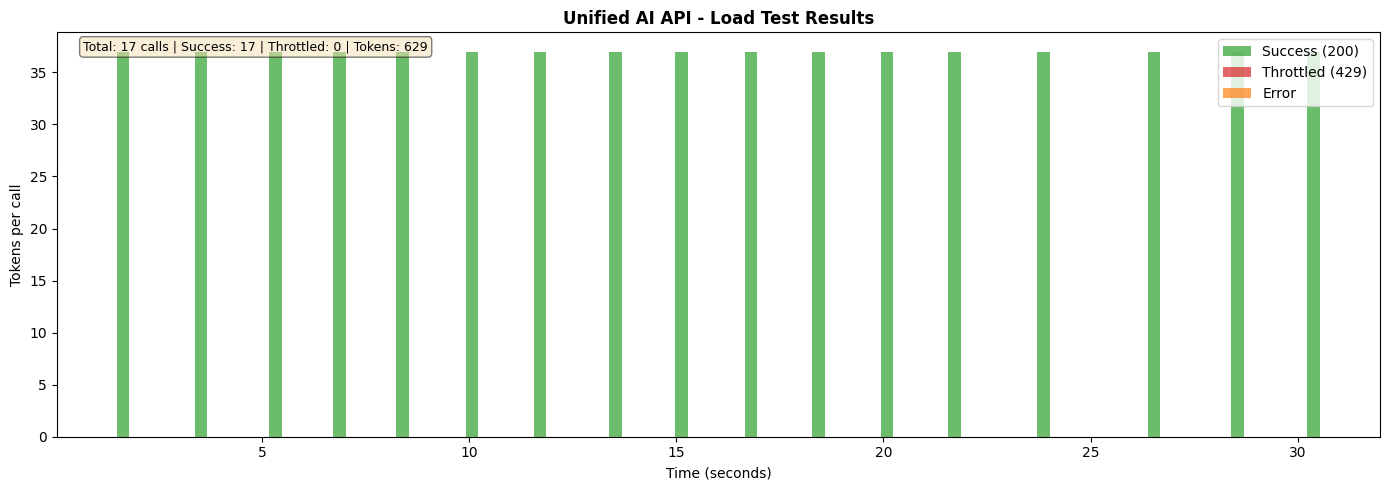

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

if api_runs:
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    times = [r[3] for r in api_runs]
    tokens = [r[1] for r in api_runs]
    status_codes = [r[2] for r in api_runs]

    colors = [
        'tab:green' if code == 200
        else 'tab:red' if code == 429
        else 'tab:orange'
        for code in status_codes
    ]

    ax.bar(times, tokens, color=colors, width=0.3, alpha=0.7)

    throttled_times = [t for t, code in zip(times, status_codes) if code == 429]
    if throttled_times:
        max_tokens = max(tokens) if tokens else 1
        ax.scatter(throttled_times, [max_tokens * 0.05] * len(throttled_times),
                  marker='x', s=50, color='darkred', zorder=5)

    total_tokens = sum(tokens)
    stats_text = f"Total: {len(api_runs)} calls | Success: {success} | Throttled: {throttled} | Tokens: {total_tokens}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_title('Unified AI API - Load Test Results', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)')
    ax.set_ylabel('Tokens per call')

    legend_items = [
        Patch(facecolor='tab:green', alpha=0.7, label='Success (200)'),
        Patch(facecolor='tab:red', alpha=0.7, label='Throttled (429)'),
        Patch(facecolor='tab:orange', alpha=0.7, label='Error'),
    ]
    ax.legend(handles=legend_items, loc='upper right')

    plt.tight_layout()
    plt.show()
else:
    print('No data to visualize. Run the load test first.')

## Test 7 — UAIG Debug Response Headers

Validate that all `UAIG-*` debug response headers are populated when `enableResponseHeaders` is enabled in the product policy.
These headers expose internal gateway state for debugging and observability.

In [14]:
utils.print_info(f"Testing UAIG debug headers with model: {openai_model}")

# Expected UAIG headers set by the Unified AI API fragments
expected_headers = [
    "UAIG-Auth-Type",        # From security-handler
    "UAIG-User-Id",          # From security-handler
    "UAIG-Subscription",     # From security-handler
    "UAIG-Model-Id",         # From request-processor
    "UAIG-API-Type",         # From request-processor
    "UAIG-Processed-Path",   # From request-processor
    "UAIG-API-Version",      # From request-processor
    "UAIG-Is-Streaming",     # From request-processor
    "UAIG-Backend",          # From set-target-backend-pool
    "UAIG-Final-Path",       # From path-builder
    "UAIG-Cache-Operation",  # From central-cache-manager
]

try:
    response = requests.post(
        openai_url,
        headers={'api-key': api_key},
        json={"messages": [{"role": "user", "content": "Hi"}]},
        timeout=30
    )

    utils.print_response_code(response)

    if response.status_code == 200:
        all_present = True
        for header in expected_headers:
            value = response.headers.get(header, None)
            if value and value != "not-set":
                utils.print_ok(f"  ✅ {header}: {value}")
            elif value == "not-set":
                utils.print_error(f"  ⚠️ {header}: not-set (fragment may not have executed)")
                all_present = False
            else:
                utils.print_error(f"  ❌ {header}: MISSING")
                all_present = False

        if all_present:
            utils.print_ok("All UAIG debug headers are present and populated!")
        else:
            utils.print_error("Some UAIG headers are missing or not set")

        # Validate expected values for known fields
        api_type = response.headers.get("UAIG-API-Type", "")
        if api_type == "openai":
            utils.print_ok(f"  ✅ API Type correctly detected as 'openai'")
        else:
            utils.print_error(f"  ❌ Expected API Type 'openai', got '{api_type}'")

        is_streaming = response.headers.get("UAIG-Is-Streaming", "")
        if is_streaming == "false":
            utils.print_ok(f"  ✅ Is-Streaming correctly set to 'false'")
        else:
            utils.print_error(f"  ❌ Expected Is-Streaming 'false', got '{is_streaming}'")

        cache_op = response.headers.get("UAIG-Cache-Operation", "")
        if cache_op in ["cache-hit", "cache-miss"]:
            utils.print_ok(f"  ✅ Cache-Operation is valid: '{cache_op}'")
        else:
            utils.print_error(f"  ❌ Unexpected Cache-Operation: '{cache_op}'")
    else:
        utils.print_error(f"Request failed with status {response.status_code}: {response.text[:300]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Testing UAIG debug headers with model: gpt-5.2
Response status: 200 - OK
✅   ✅ UAIG-Auth-Type: api-key ⌚ 17:48:12.469809 
✅   ✅ UAIG-User-Id: LLM-Testing-UnifiedAI-DEV-SUB-01 ⌚ 17:48:12.469809 
✅   ✅ UAIG-Subscription: LLM-Testing-UnifiedAI-DEV-SUB-01 ⌚ 17:48:12.469809 
✅   ✅ UAIG-Model-Id: gpt-5.2 ⌚ 17:48:12.469809 
✅   ✅ UAIG-API-Type: openai ⌚ 17:48:12.469809 
✅   ✅ UAIG-Processed-Path: /openai/deployments/gpt-5.2/chat/completions ⌚ 17:48:12.469809 
✅   ✅ UAIG-API-Version: 2024-02-15-preview ⌚ 17:48:12.469809 
✅   ✅ UAIG-Is-Streaming: false ⌚ 17:48:12.469809 
✅   ✅ UAIG-Backend: aif-dmdxocmlhenr4-1 ⌚ 17:48:12.469809 
✅   ✅ UAIG-Final-Path: /openai/deployments/gpt-5.2/chat/completions ⌚ 17:48:12.469809 
✅   ✅ UAIG-Cache-Operation: cache-miss ⌚ 17:48:12.469809 
✅ All UAIG debug headers are present and populated! ⌚ 17:48:12.469809 
✅   ✅ API Type correctly detected as 'openai' ⌚ 17:48:12.469809 
✅   ✅ Is-Streaming correctly set to 'false' ⌚ 17:48:12.469809 
✅   ✅ Cache-Operation is 

## Test 8 — Blocked Path Rejection

Validate that the `request-processor` fragment rejects requests to paths that don't match any configured API type base-path.
The expected response is `403 Forbidden` with error code `PathNotAllowed`.

In [15]:
base_url_clean = azure_endpoint.rstrip('/')

# Test paths that don't match any configured api-type base-path
blocked_paths = [
    "/unified-ai/invalid-path/chat/completions",
    "/unified-ai/some/random/endpoint",
    "/unified-ai/v2/openai/chat/completions",
]

for path in blocked_paths:
    url = f"{base_url_clean}{path}"
    utils.print_info(f"Testing blocked path: {path}")

    try:
        response = requests.post(
            url,
            headers={'api-key': api_key},
            json={"model": openai_model, "messages": [{"role": "user", "content": "Hi"}]},
            timeout=30
        )

        if response.status_code == 403:
            try:
                error_data = json.loads(response.text)
                error_code = error_data.get("error", {}).get("code", "")
                if error_code == "PathNotAllowed":
                    utils.print_ok(f"  ✅ Correctly blocked with 403 PathNotAllowed")
                else:
                    utils.print_ok(f"  ✅ Correctly returned 403 (code: {error_code})")
            except json.JSONDecodeError:
                utils.print_ok(f"  ✅ Correctly returned 403")
        else:
            utils.print_error(f"  ❌ Expected 403, got {response.status_code}: {response.text[:200]}")
    except Exception as e:
        utils.print_error(f"  Request failed: {e}")

👉🏽 Testing blocked path: /unified-ai/invalid-path/chat/completions
✅   ✅ Correctly blocked with 403 PathNotAllowed ⌚ 17:48:13.160209 
👉🏽 Testing blocked path: /unified-ai/some/random/endpoint
✅   ✅ Correctly blocked with 403 PathNotAllowed ⌚ 17:48:13.852879 
👉🏽 Testing blocked path: /unified-ai/v2/openai/chat/completions
❌   ❌ Expected 403, got 200: {"choices":[{"content_filter_results":{"hate":{"filtered":false,"severity":"safe"},"protected_material_code":{"detected":false,"filtered":false},"protected_material_text":{"detected":false,"filtered": ⌚ 17:48:15.789406 


## Test 9 — Model Access Control (allowedModels)

Validate that the `validate-model-access` fragment enforces the `allowedModels` restriction set in the access contract product policy.
Requesting a model not in the allowed list should be rejected.

In [18]:
# The access contract was configured with allowedModels limited to openai_model and foundry_inference_model
# (and optionally gemini_model). A model outside this list should be rejected.
blocked_model = "some-unauthorized-model-xyz"
utils.print_info(f"Testing model access control with unauthorized model: {blocked_model}")

blocked_model_url = f"{azure_endpoint.rstrip('/')}/unified-ai/models/chat/completions?api-version={inference_api_version}"

try:
    response = requests.post(
        blocked_model_url,
        headers={'api-key': api_key},
        json={
            "model": blocked_model,
            "messages": [{"role": "user", "content": "Hi"}]
        },
        timeout=30
    )

    if response.status_code == 403:
        utils.print_ok(f"✅ Unauthorized model correctly blocked: {response.status_code}")
        try:
            error_data = json.loads(response.text)
            utils.print_info(f"   Error: {error_data.get('error', {}).get('message', response.text[:200])}")
        except json.JSONDecodeError:
            pass
    elif response.status_code == 400:
        utils.print_ok(f"✅ Unauthorized model rejected: {response.status_code}")
        try:
            error_data = json.loads(response.text)
            utils.print_info(f"   Error: {error_data.get('error', {}).get('message', response.text[:200])}")
        except json.JSONDecodeError:
            pass
    else:
        utils.print_error(f"❌ Expected 403 or 400, got {response.status_code}: {response.text[:300]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

# Verify an allowed model still works
utils.print_info(f"Confirming allowed model still works: {openai_model}")

try:
    response = requests.post(
        openai_url,
        headers={'api-key': api_key},
        json={"messages": [{"role": "user", "content": "Say OK"}]},
        timeout=30
    )

    if response.status_code == 200:
        utils.print_ok(f"✅ Allowed model accepted: {response.status_code}")
    else:
        utils.print_error(f"❌ Allowed model rejected: {response.status_code}")
except Exception as e:
        utils.print_error(f"  Request failed: {e}")

👉🏽 Testing model access control with unauthorized model: some-unauthorized-model-xyz
❌ ❌ Expected 403 or 400, got 401: {
  "error": {
    "message": "Access to model 'some-unauthorized-model-xyz' is not allowed for this product.",
    "type": "access_error",
    "code": "unauthorized_model_access",
    "allowed_models": "gpt-5.2,Mistral-Large-3"
  }
} ⌚ 18:03:05.863220 
👉🏽 Confirming allowed model still works: gpt-5.2
✅ ✅ Allowed model accepted: 200 ⌚ 18:03:07.638359 


## Test 10 — Invalid API Key

Validate that an incorrect API key is rejected (as opposed to just a missing key tested earlier).
This tests the APIM subscription validation layer.

In [19]:
utils.print_info("Testing with invalid (wrong) API key...")

try:
    response = requests.post(
        openai_url,
        headers={'api-key': 'invalid-api-key-00000000000000000000'},
        json={"messages": [{"role": "user", "content": "Hi"}]},
        timeout=30
    )

    if response.status_code == 401:
        utils.print_ok(f"✅ Invalid API key correctly rejected: {response.status_code} (expected 401)")
    else:
        utils.print_error(f"❌ Invalid API key: {response.status_code} (expected 401)")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

# Test with an API key from a different subscription (if another subscription exists)
utils.print_info("Testing with API key against wrong API path (cross-product)...")

try:
    # Use the valid key but against a path not associated with this product
    wrong_path_url = f"{azure_endpoint.rstrip('/')}/openai/deployments/{openai_model}/chat/completions?api-version={openai_api_version}"
    response = requests.post(
        wrong_path_url,
        headers={'api-key': api_key},
        json={"messages": [{"role": "user", "content": "Hi"}]},
        timeout=30
    )

    if response.status_code in [401, 403]:
        utils.print_ok(f"✅ Cross-product access correctly rejected: {response.status_code}")
    elif response.status_code == 200:
        utils.print_info(f"ℹ️ Cross-product access allowed (key may be associated with multiple products): {response.status_code}")
    else:
        utils.print_info(f"ℹ️ Cross-product response: {response.status_code}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Testing with invalid (wrong) API key...
✅ ✅ Invalid API key correctly rejected: 401 (expected 401) ⌚ 18:04:04.047043 
👉🏽 Testing with API key against wrong API path (cross-product)...
✅ ✅ Cross-product access correctly rejected: 401 ⌚ 18:04:04.784894 


## Test 11 — Streaming Request

Test that the `request-processor` correctly detects `stream: true` in the request body and the gateway handles streaming responses.
The `UAIG-Is-Streaming` header should reflect `true`, and the response should be a streamed SSE response.

In [21]:
utils.print_info(f"Testing streaming request with model: {openai_model}")

streaming_messages = {
    "messages": [
        {"role": "user", "content": "Count from 1 to 10."}
    ],
    "stream": True
}

try:
    response = requests.post(
        openai_url,
        headers={'api-key': api_key},
        json=streaming_messages,
        timeout=60,
        stream=True
    )

    utils.print_response_code(response)

    if response.status_code == 200:
        # Verify streaming header detection
        is_streaming_header = response.headers.get("UAIG-Is-Streaming", "not-set")
        if is_streaming_header == "true":
            utils.print_ok(f"  ✅ UAIG-Is-Streaming: {is_streaming_header} (correctly detected)")
        else:
            utils.print_error(f"  ❌ UAIG-Is-Streaming: {is_streaming_header} (expected 'true')")

        # Read and count streamed chunks (SSE format: data: {...}\n\n)
        chunk_count = 0
        content_parts = []
        for line in response.iter_lines(decode_unicode=True):
            if line and line.startswith("data: "):
                data_str = line[6:]  # Remove "data: " prefix
                if data_str.strip() == "[DONE]":
                    break
                try:
                    chunk = json.loads(data_str)
                    delta = chunk.get("choices", [{}])[0].get("delta", {})
                    content = delta.get("content", "")
                    if content:
                        content_parts.append(content)
                    chunk_count += 1
                except json.JSONDecodeError:
                    pass

        full_response = "".join(content_parts)
        utils.print_ok(f"  ✅ Received {chunk_count} SSE chunks")
        utils.print_ok(f"  💬 Streamed response: {full_response[:200]}")

        # Verify other UAIG headers are present in streaming response
        backend = response.headers.get("UAIG-Backend", "not-set")
        api_type = response.headers.get("UAIG-API-Type", "not-set")
        utils.print_info(f"   Backend: {backend}")
        utils.print_info(f"   API Type: {api_type}")
    else:
        utils.print_error(f"Error: {response.text[:300]}")
except Exception as e:
    utils.print_error(f"Request failed: {e}")

👉🏽 Testing streaming request with model: gpt-5.2
Response status: 200 - OK
✅   ✅ UAIG-Is-Streaming: true (correctly detected) ⌚ 18:05:14.616397 
❌ Request failed: list index out of range ⌚ 18:05:14.617399 


## Summary

| Test | Pattern | Expected |
|------|---------|----------|
| Access Contract | Deploy Bicep access contract | Product + subscription created |
| Model & Deployment Discovery | `GET /unified-ai/deployments` and `GET /unified-ai/deployments/{name}` | List models, 200 for existing, 404 for non-existent |
| Azure OpenAI | `POST /unified-ai/openai/deployments/{model}/chat/completions` | 200 |
| Foundry Inference | `POST /unified-ai/models/chat/completions` (body: model) | 200 |
| Responses API | `POST /unified-ai/openai/responses` | 200 (if configured) |
| Gemini | `POST /unified-ai/v1beta/openai/chat/completions` | 200 (if configured) |
| Valid API Key | Request with api-key header | 200 |
| Missing API Key | Request without api-key header | 401 |
| Load Test | 30s burst requests | Mix of 200/429 |
| UAIG Debug Headers | Validate all UAIG-* response headers | All headers present and populated |
| Blocked Path | `POST /unified-ai/invalid-path/...` | 403 PathNotAllowed |
| Model Access Control | Request unauthorized model | 403 or 400 |
| Invalid API Key | Request with wrong api-key value | 401 |
| Streaming | `POST` with `stream: true` | 200 SSE stream, UAIG-Is-Streaming: true |

---
### 🧹 Cleanup

Remove the test access contract from APIM created during this notebook session:

In [ ]:
# Set to True to delete the access contract created in this session
cleanup_enabled = False

if cleanup_enabled:
    utils.print_info(f"Deleting access contract product: {product_id}...")

    prod_cmd = f"az apim product delete --resource-group {governance_hub_resource_group} --service-name {apimClientTool.apim_resource_name} --product-id {product_id} --delete-subscriptions true --yes"
    utils.run(prod_cmd, f"Deleted product {product_id}", f"Failed to delete product {product_id}")

    utils.print_ok("Cleanup completed!")
else:
    utils.print_info("Cleanup is disabled. Set cleanup_enabled = True to remove test resources.")